In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

In [123]:
# Champ de ggd 
l = 500
a, b = 100, 100
ggd = np.zeros((l, l))
for x in range(l) : 
    for y in range(l) : 
        ggd[x, y] = a*x+b

ggd = xr.DataArray(data = ggd, 
                   coords=dict(x = (['x'], np.arange(0,l)),y = (['y'], np.arange(0,l))))


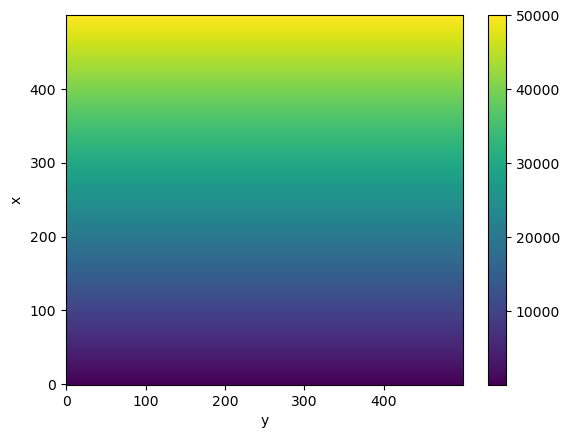

In [124]:
ggd.plot()

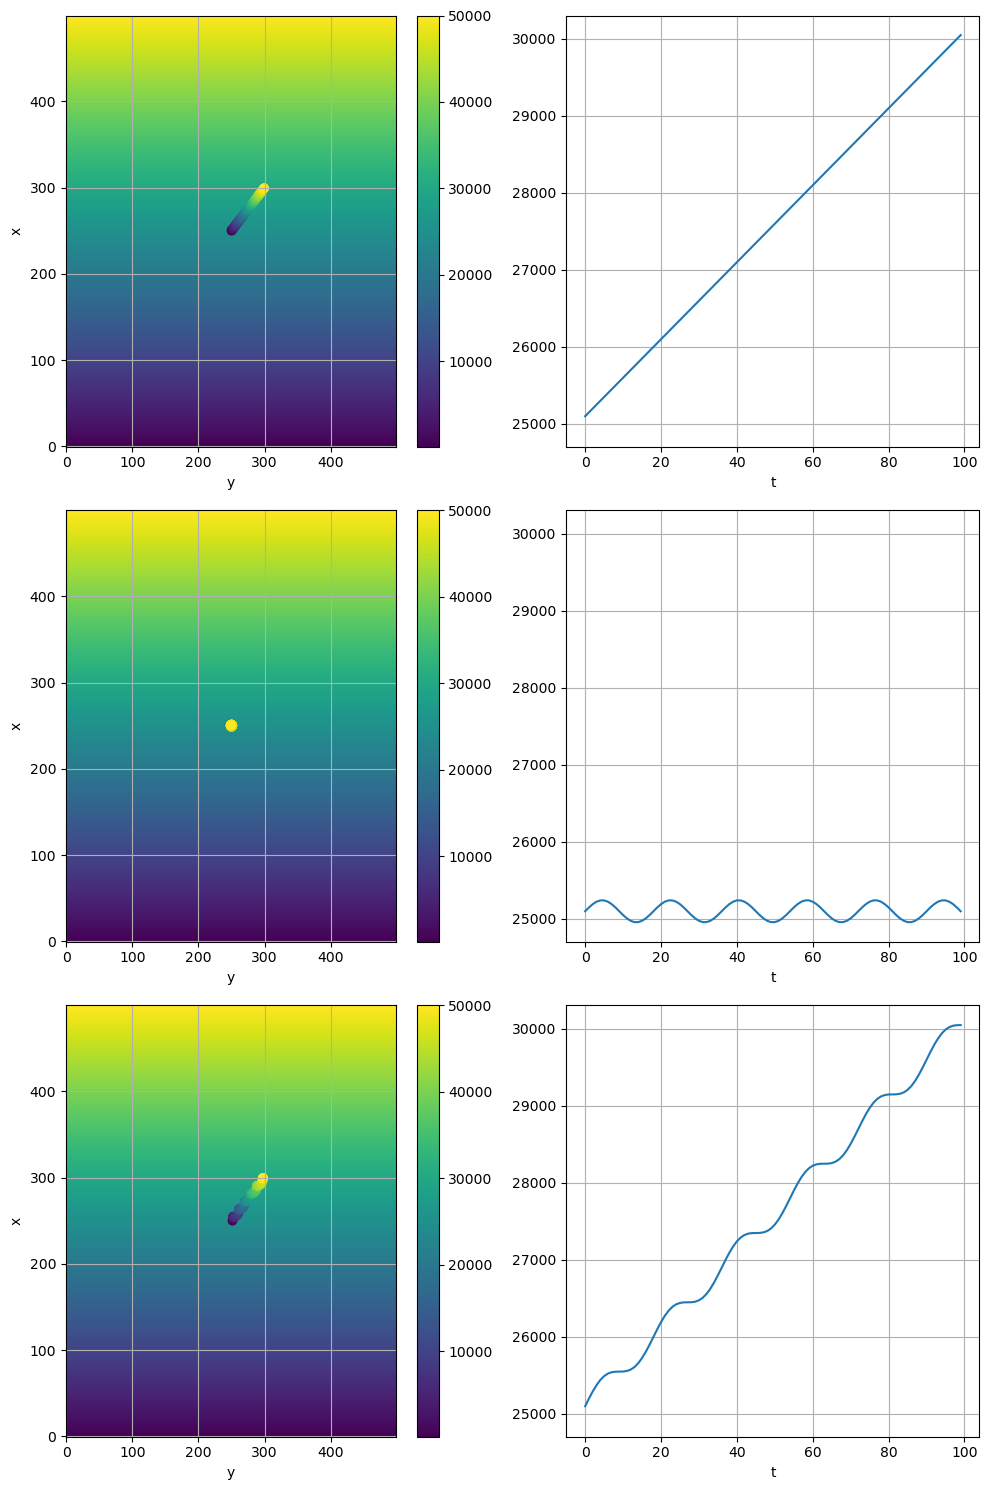

In [132]:
t = np.arange(0, 100)
T = 18

def traj(t, uy, ux, ui, T) :
    ai = T/2/np.pi*ui
    trajx = ai*np.cos(2*np.pi*t/T)+l/2+ux*t
    trajy = ai*np.sin(2*np.pi*t/T) + uy*t+l/2
    return trajx, trajy
    
def plot(ax1, ax2, trajx, trajy) : 
    ggd.plot(ax=ax1)
    ax1.scatter(trajx, trajy, c=t/5)
    ggd.interp(x=('t', trajy), y=('t',trajx),).plot(ax=ax2)
    ax1.grid()
    ax2.grid()

fig, axs = plt.subplots(3, 2, frameon=False, figsize=(10,15), sharey='col')
axs=axs.flatten()
trajx, trajy = traj(t, uy = 0.5, ux = 0.5, ui = 0, T=T)
plot(axs[0], axs[1], trajx, trajy)

trajx, trajy = traj(t, uy = 0, ux= 0, ui = 0.5, T=T)
plot(axs[2], axs[3], trajx, trajy)

trajx, trajy = traj(t, uy = 0.5, ux = 0.5, ui = 0.5, T=T)
plot(axs[4], axs[5], trajx, trajy)

#trajx, trajy = traj(t, uy = 0.5, ui = 0, T=T)
#plot(axs[6], axs[7], trajx, trajy)

fig.tight_layout()
